In [1]:
# データを用意
import numpy as np
X = np.array([[0.0], [2.0], [3.9], [4.0]])
Y = np.array([4.0, 0.0, 3.0, 2.0])

# 1次元データを拡張
# ・1次元目（頭の「1」）は、0乗した値（バイアス項）。
# ・2次元目は、元のデータ。
# ・3次元目は、2乗（degree=2）した値。
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X2 = poly.fit_transform(X)
print(X2)

[[ 1.    0.    0.  ]
 [ 1.    2.    4.  ]
 [ 1.    3.9  15.21]
 [ 1.    4.   16.  ]]


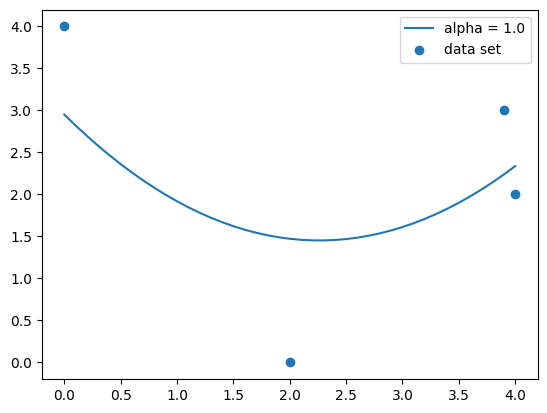

In [2]:
# 学習機の用意、学習
from sklearn.linear_model import Ridge
clf = Ridge(alpha=1.0)
clf.fit(X2, Y)

# 描画
%matplotlib inline
import matplotlib.pyplot as plt

samples_x = np.arange(0, 4.1, 0.1)
samples_x2 = poly.fit_transform(samples_x.reshape(len(samples_x), 1))
samples_y = clf.predict(samples_x2)
plt.plot(samples_x, samples_y, label='alpha = 1.0')
plt.scatter(X, Y, label='data set')
plt.legend()

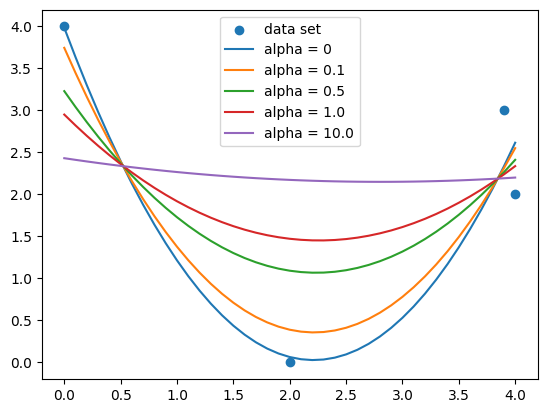

In [3]:
alphas = [0, 0.1, 0.5, 1.0, 10.0]

plt.scatter(X, Y, label='data set')

for alpha in alphas:
    clf = Ridge(alpha = alpha)
    clf.fit(X2, Y)
    samples_y = clf.predict(samples_x2)
    plt.plot(samples_x, samples_y, label=f'alpha = {alpha}')

plt.legend()
plt.show()